# What's Really Inside the S&P 500?
## Phase 3: Concentration Analysis

**Central Question:** What's really inside the S&P 500? Analyzing the composition, concentration, and turnover of the world's most popular index to understand what investors are actually buying.

---

### Overview

In Phase 2, I found that Information Technology dominates the S&P 500 - roughly 30% of the total market cap despite having fewer companies than Industrials and Financials. That was the *sector* view.

Now zooming in further and aksing the *company-level* question: how much of the index is controlled by just a handful of individual stocks? If the top 10 companies make up a third of the entire index, what does that mean for the 490+ other, and for investors who think they're getting diversification?

This phase covers four things:

1. **Top-N concentration snapshots** - What share of total market cap do the top 5, 10, and 25 companies hold?
2. **Cumulative weight curve** - A visual showing how quickly market cap accumulates as you move down the ranked list of companies.
3. **Top 20 vs. the index** - Comparing the growth of the biggest stocks against the S&P 500 as a whole.
4. **Herfindahl-Hirschman Index (HHI)** - A standard economic measure that captures concentration in a single number.

---
## Step 1: Libraries and Data

Libraries used:
- **pandas** - data manipulation and analysis
- **matplotlib/seaborn** - data visualization 

Datasets used:
- `sp500_companies_market_cap.csv` - market cap for all 503 companies
- `top20_price_history.csv` - daily close prices for the top 20 companies by market cap
- `sp500_index_history.csv` - 10 years of daily S&P 500 index prices


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
companies = pd.read_csv('data/sp500_companies_market_cap.csv')
top20_prices = pd.read_csv('data/top20_price_history.csv')
sp500 = pd.read_csv('data/sp500_index_history.csv')

### 1A: Data Check

In [5]:
print(f'Companies: {companies.shape}')
print(f'Top 20 prices: {top20_prices.shape}')
print(f'S&P 500 index: {sp500.shape}')

Companies: (503, 9)
Top 20 prices: (2513, 21)
S&P 500 index: (2515, 6)


---

## Step 2: Top-N Concentration Snapshots

This is the simplest and most powerful way to show concentration: just answering the question "what percentage of the entire index do the top N companies represent?"

I will:
1. Sort by `market_cap` descending
2. Calculate the total market cap of the entire index
3. Sum the market cap for the top 5, 10, and 25
4. Divide each by the total to get percentages

These numbers are the headline finding of this phase.

### 2A: Sort and calculate total market cap

In [6]:
print(companies.columns.tolist())

['ticker', 'company', 'sector', 'sub_industry', 'headquarters', 'date_added', 'founded', 'market_cap', 'market_cap_billions']


In [8]:
#Sorting companies by market cap, largest first
companies = companies.sort_values('market_cap', ascending=False).reset_index(drop=True)

#Total market cap of the entire index
total_market_cap = companies['market_cap'].sum()
print(f'Total S&P 500 market cap: ${total_market_cap/1e12:.2f} trillion')

Total S&P 500 market cap: $62.58 trillion


### 2B: Top-N percentages

3 groups (top 5, top 10, top 25) will calculated as percentages

In [11]:
#Calculating the top-N concentration
for n in [5, 10, 25]:
    top_n_cap = companies.head(n)['market_cap'].sum()
    pct = (top_n_cap / total_market_cap) * 100
    print(f'Top {n:>2} companies: ${top_n_cap / 1e12:.2f}T -> {pct:.1f}% of the index')
    
#The actual top 10
print(f'Top 10 companies:')
print(companies[['ticker', 'company', 'market_cap_billions']].head(10).to_string(index=False))

Top  5 companies: $17.39T -> 27.8% of the index
Top 10 companies: $24.89T -> 39.8% of the index
Top 25 companies: $32.90T -> 52.6% of the index
Top 10 companies:
ticker                 company  market_cap_billions
  NVDA                  Nvidia          4161.988461
  AAPL              Apple Inc.          3716.958388
 GOOGL Alphabet Inc. (Class A)          3398.289588
  GOOG Alphabet Inc. (Class C)          3396.111696
  MSFT               Microsoft          2720.027378
  AMZN                  Amazon          2227.925418
  AVGO                Broadcom          1467.021263
  TSLA             Tesla, Inc.          1396.317356
  META          Meta Platforms          1385.032712
 BRK-B      Berkshire Hathaway          1025.096024


### 2C: Top-N concentration visual

Chart for each group (top 5, 10, 25)



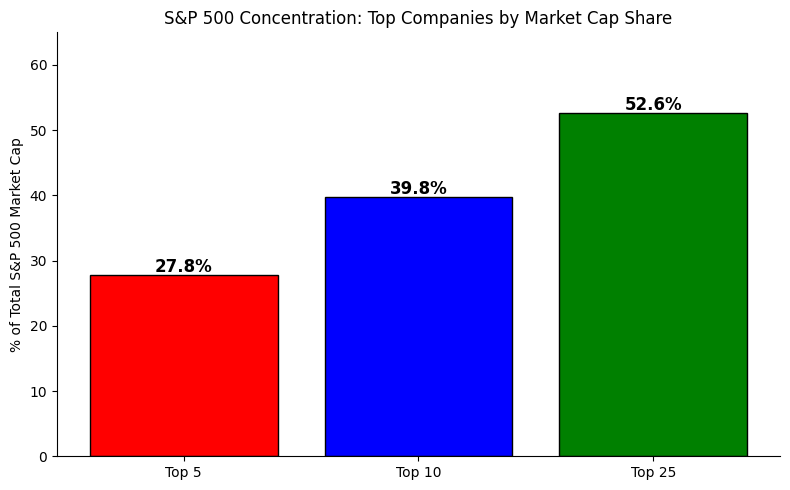

In [28]:
#Concentration bar chart
labels = ['Top 5', 'Top 10', 'Top 25']
percentages = []

for n in [5, 10, 25]:
    pct = (companies.head(n)['market_cap'].sum() / total_market_cap) * 100
    percentages.append(pct)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, percentages, color=['Red', 'Blue', 'Green'], edgecolor='black')

#Labeling each bar
for bar, pct in zip(bars, percentages):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, 
            f'{pct:.1f}%', ha='center', fontsize=12, fontweight='bold')

ax.set_ylabel('% of Total S&P 500 Market Cap')
ax.set_title('S&P 500 Concentration: Top Companies by Market Cap Share')
ax.set_ylim(0, 65)
sns.despine()
plt.tight_layout()
plt.show()